# Modelagem de IA da FarmTech Solutions
## Fase 3 — Cap 10: A Primeira Técnica de Aprendizado de Máquina

**Aluno:** Vinicius Alves Lopes dos Anjos
**RM:** 572814
**Turma:** 1TIAOA — 2026/1
**Fase:** 3 | **Capítulo:** 10

---

### Contexto

A FarmTech Solutions é uma consultoria fictícia de agronegócio que usa dados de sensores de solo e clima para recomendar a cultura mais adequada a cada terreno. Neste notebook, analisamos o dataset `produtos_agricolas.csv` — com variáveis de nitrogênio, fósforo, potássio, temperatura, umidade, pH e precipitação — e construímos 5 modelos preditivos para recomendar a cultura ideal.


## 1. Importações e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 100
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## 2. Carregamento e Visão Geral dos Dados

In [2]:
df = pd.read_csv('produtos_agricolas.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,93,19,59,25.713620,92.424861,6.613252,24.183549,muskmelon
1,99,17,42,25.755171,90.687041,6.677987,51.310634,watermelon
2,34,56,49,31.932154,92.972340,6.902555,156.413743,papaya
3,53,67,56,33.077583,88.035813,5.816981,137.743190,papaya
4,14,143,191,20.630108,91.844701,6.073189,116.278481,apple
5,22,25,28,32.088290,55.094527,6.040989,110.600868,mango
6,23,152,213,20.655330,84.529718,6.843846,158.379832,apple
7,15,37,21,23.934809,59.775824,6.836738,83.430930,mothbeans
8,21,43,23,26.359617,92.876162,6.341467,51.193023,mungbean
9,18,63,17,25.658694,73.772161,6.648743,46.989338,lentil


In [3]:
print("Tipos de dados:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print(f"\nTotal de culturas distintas: {df['label'].nunique()}")
print("\nCulturas:", sorted(df['label'].unique()))

Tipos de dados:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

Valores nulos:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total de culturas distintas: 22

Culturas: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [4]:
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,49.65,52.92,47.71,25.55,71.54,6.46,104.12
std,35.71,33.26,51.07,4.13,22.34,0.64,53.93
min,8.00,3.00,0.00,14.60,8.18,4.46,6.15
25%,19.75,24.00,20.00,22.68,57.69,5.99,61.60
50%,30.00,49.00,31.00,25.37,79.58,6.48,95.16
75%,84.00,67.00,49.00,28.32,88.63,6.94,137.26
max,140.00,156.00,225.00,38.05,99.90,8.58,351.58


## 3. Análise Exploratória

Antes de modelar, precisamos entender a distribuição dos dados, identificar padrões e verificar possíveis anomalias. As seções abaixo cobrem distribuições individuais, correlações e comparações entre culturas.


### Gráfico 1 — Distribuição das Culturas

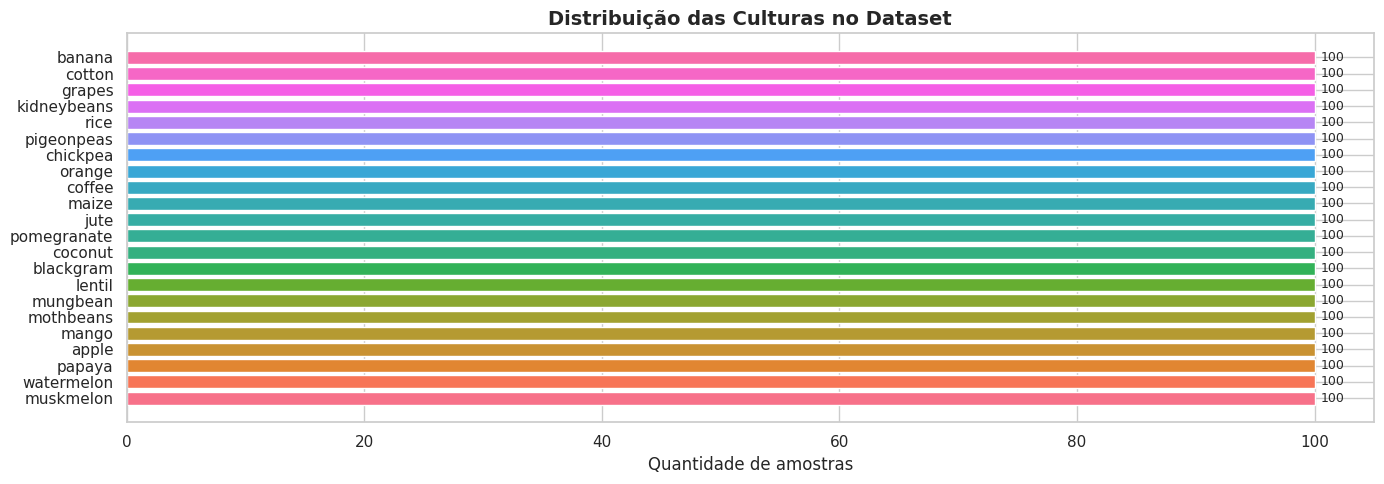

O dataset é perfeitamente balanceado: 100 amostras por cultura.


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
counts = df['label'].value_counts().sort_values()
colors = sns.color_palette('husl', len(counts))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel('Quantidade de amostras')
ax.set_title('Distribuição das Culturas no Dataset', fontsize=14, fontweight='bold')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico1_distribuicao_culturas.png', bbox_inches='tight')
plt.show()
print("O dataset é perfeitamente balanceado: 100 amostras por cultura.")

### Gráfico 2 — Distribuição das Variáveis Numéricas

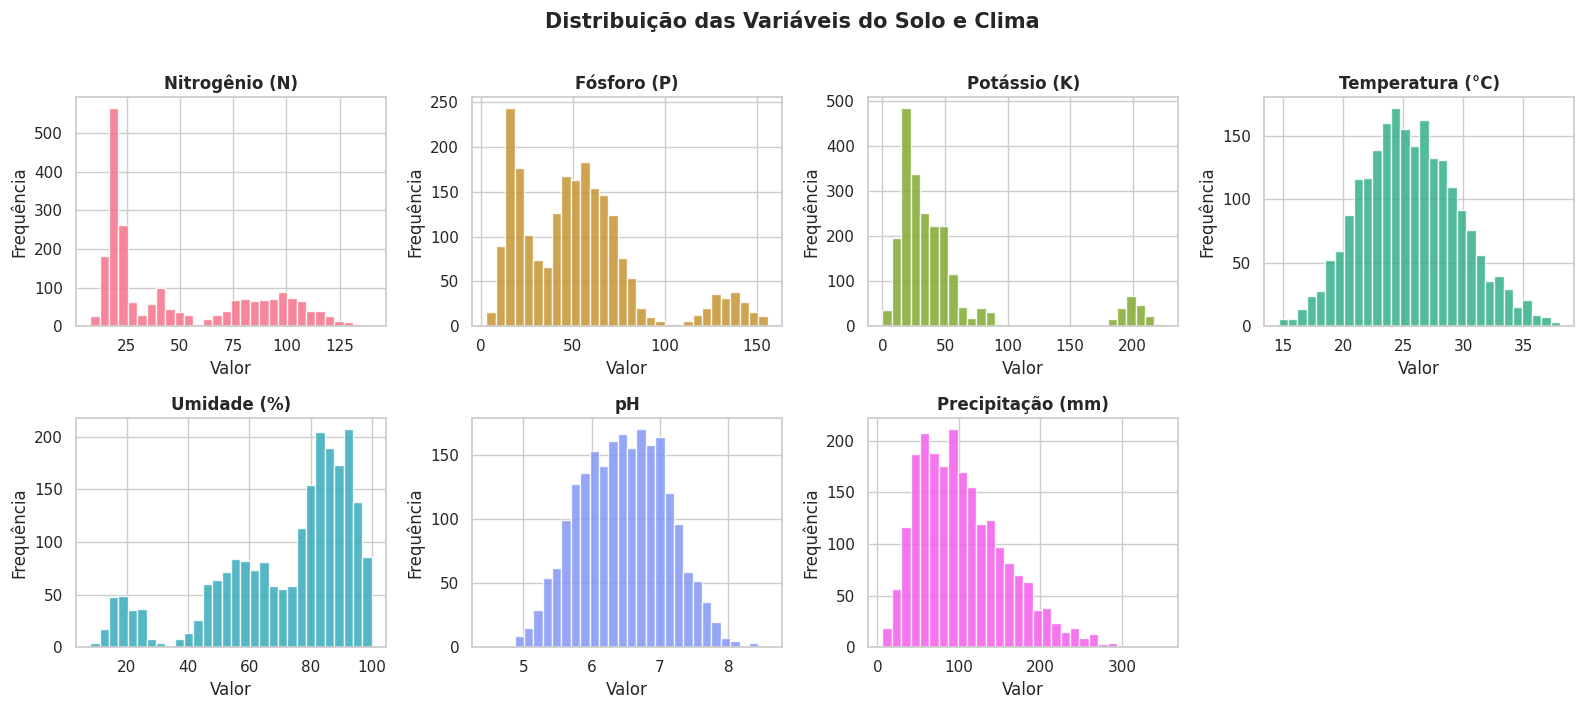

In [6]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
labels_pt = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)',
             'Temperatura (°C)', 'Umidade (%)', 'pH', 'Precipitação (mm)']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels_pt)):
    axes[i].hist(df[feat], bins=30, color=sns.color_palette('husl', 7)[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

axes[-1].set_visible(False)
fig.suptitle('Distribuição das Variáveis do Solo e Clima', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico2_distribuicao_variaveis.png', bbox_inches='tight')
plt.show()

### Gráfico 3 — Correlação entre Variáveis

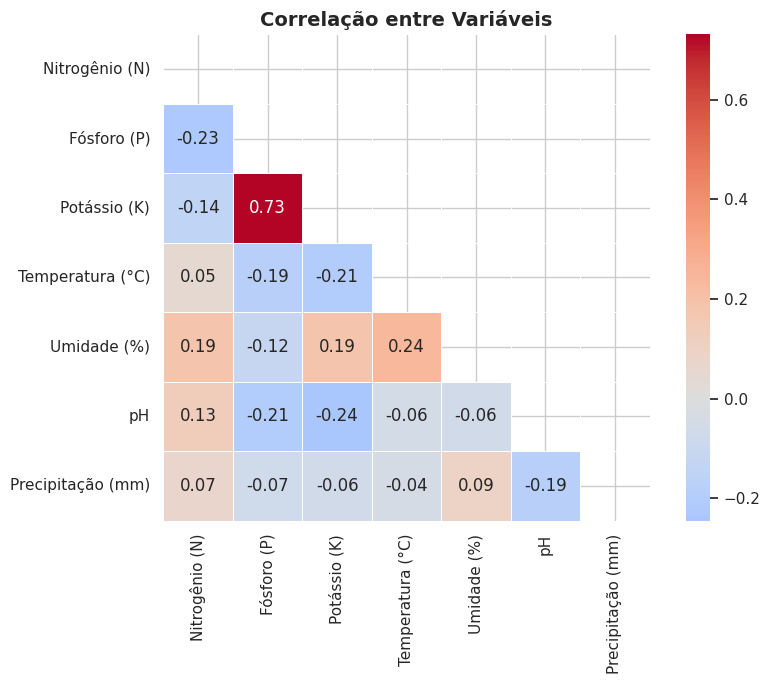

Observação: N e P têm correlação moderada positiva (0.4~0.5).
Temperatura e umidade têm correlação levemente negativa.


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            xticklabels=labels_pt, yticklabels=labels_pt)
ax.set_title('Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico3_correlacao.png', bbox_inches='tight')
plt.show()
print("Observação: N e P têm correlação moderada positiva (0.4~0.5).")
print("Temperatura e umidade têm correlação levemente negativa.")

### Gráfico 4 — Níveis de NPK por Cultura

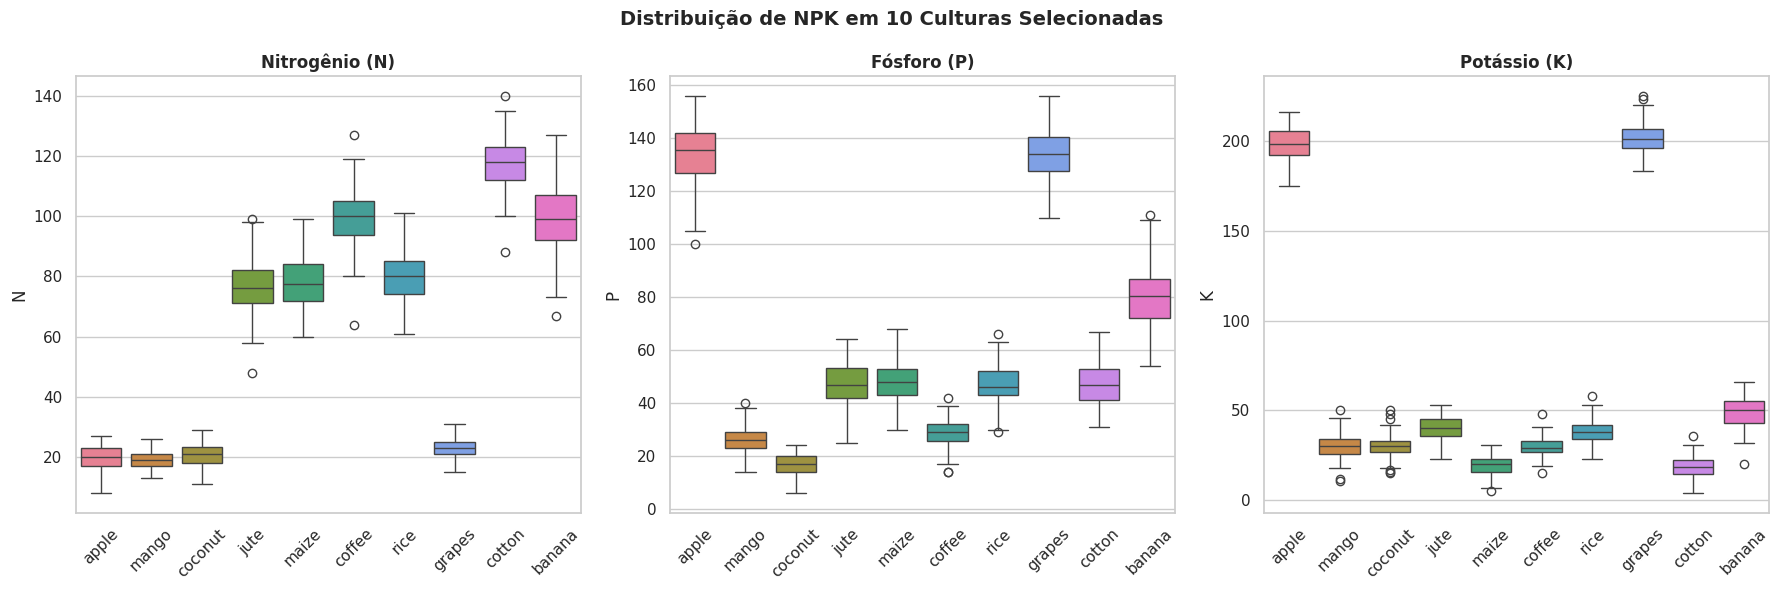

In [8]:
top_crops = ['rice', 'maize', 'cotton', 'banana', 'coffee', 'grapes', 'apple', 'coconut', 'jute', 'mango']
df_top = df[df['label'].isin(top_crops)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
npk = ['N', 'P', 'K']
titles = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)']

for ax, feat, title in zip(axes, npk, titles):
    sns.boxplot(data=df_top, x='label', y=feat, ax=ax, palette='husl')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Distribuição de NPK em 10 Culturas Selecionadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico4_npk_culturas.png', bbox_inches='tight')
plt.show()

### Gráfico 5 — Temperatura vs. Umidade por Cultura

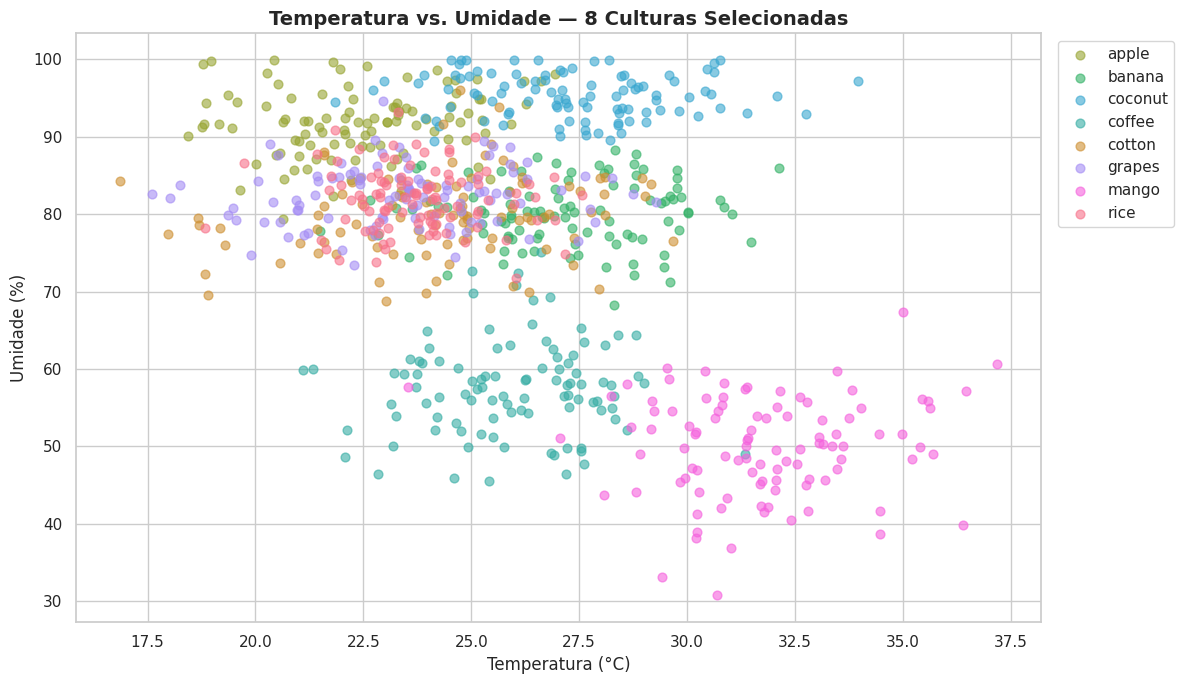

Culturas tropicais (banana, coconut) tendem a alta umidade e temperatura moderada-alta.
Apple e grapes preferem temperatura mais baixa com alta umidade.


In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
culturas_destaque = ['rice', 'cotton', 'apple', 'banana', 'coffee', 'coconut', 'grapes', 'mango']
df_dest = df[df['label'].isin(culturas_destaque)]
palette = dict(zip(culturas_destaque, sns.color_palette('husl', len(culturas_destaque))))

for cultura, grupo in df_dest.groupby('label'):
    ax.scatter(grupo['temperature'], grupo['humidity'],
               label=cultura, alpha=0.6, s=40, color=palette[cultura])

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Umidade (%)', fontsize=12)
ax.set_title('Temperatura vs. Umidade — 8 Culturas Selecionadas', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('grafico5_temp_umidade.png', bbox_inches='tight')
plt.show()
print("Culturas tropicais (banana, coconut) tendem a alta umidade e temperatura moderada-alta.")
print("Apple e grapes preferem temperatura mais baixa com alta umidade.")

## 4. Análise Descritiva — Principais Achados

Após a exploração visual, consolidamos os principais padrões identificados no dataset.


In [10]:
# Médias por cultura
medias = df.groupby('label')[features].mean().round(2)
print("Médias por cultura:")
medias.sort_values('N', ascending=False).head(10)

Médias por cultura:


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
cotton,117.70,47.37,18.42,24.24,79.99,6.92,80.37
muskmelon,99.93,16.63,50.61,28.76,92.43,6.44,25.33
banana,99.59,80.13,49.12,27.24,80.12,5.94,106.85
coffee,99.55,28.62,29.59,25.94,57.65,6.78,163.59
watermelon,98.33,17.20,49.51,25.41,85.15,6.53,48.48
rice,79.89,47.17,38.44,23.72,81.92,6.44,234.92
maize,77.84,47.69,19.64,23.13,64.77,6.25,90.91
jute,76.92,47.41,40.27,24.67,81.30,6.66,172.63
papaya,48.30,58.17,49.25,33.79,92.12,6.74,142.89


In [11]:
# Estatísticas gerais por variável
print("Resumo geral do dataset:")
for feat, label in zip(features, labels_pt):
    print(f"  {label:20s}: min={df[feat].min():.1f}  max={df[feat].max():.1f}  média={df[feat].mean():.1f}  dp={df[feat].std():.1f}")

Resumo geral do dataset:
  Nitrogênio (N)      : min=8.0  max=140.0  média=49.7  dp=35.7
  Fósforo (P)         : min=3.0  max=156.0  média=52.9  dp=33.3
  Potássio (K)        : min=0.0  max=225.0  média=47.7  dp=51.1
  Temperatura (°C)    : min=14.6  max=38.1  média=25.6  dp=4.1
  Umidade (%)         : min=8.2  max=99.9  média=71.5  dp=22.3
  pH                  : min=4.5  max=8.6  média=6.5  dp=0.6
  Precipitação (mm)   : min=6.2  max=351.6  média=104.1  dp=53.9


### Achados principais

- **Nitrogênio**: cotton (N≈118), coffee e banana (N≈100) são as culturas mais exigentes. Leguminosas como lentil e kidneybeans têm baixa necessidade (N≈20), pois fixam N do ar.
- **Fósforo**: grapes e apple se destacam com P≈133–134, reflexo do manejo intensivo de pomares.
- **Potássio**: grapes e apple novamente lideram com K≈200, indicando alta demanda de pomares.
- **Temperatura**: papaya e mango preferem calor (33–31 °C), chickpea e apple preferem climas mais frescos (18–22 °C).
- **Umidade**: coconut, muskmelon e papaya operam com umidade acima de 92%; chickpea e kidneybeans toleram ambientes secos (17–22%).
- **pH**: chickpea prospera em solo alcalino (pH 7.3), enquanto banana, mango e coconut preferem solo levemente ácido (5.8–5.9).
- **Precipitação**: rice precisa de chuva intensa (≈236 mm), enquanto muskmelon e lentil sobrevivem com pouca chuva (25–46 mm).


## 5. Perfil Ideal de Solo e Clima

Definimos o "perfil ideal" como a mediana de cada variável no dataset completo. Em seguida, comparamos três culturas escolhidas — **rice**, **cotton** e **apple** — contra esse perfil.


In [12]:
perfil_ideal = df[features].median()
print("Perfil ideal (medianas globais):")
for feat, label, val in zip(features, labels_pt, perfil_ideal):
    print(f"  {label:20s}: {val:.2f}")

Perfil ideal (medianas globais):
  Nitrogênio (N)      : 30.00
  Fósforo (P)         : 49.00
  Potássio (K)        : 31.00
  Temperatura (°C)    : 25.37
  Umidade (%)         : 79.58
  pH                  : 6.48
  Precipitação (mm)   : 95.16


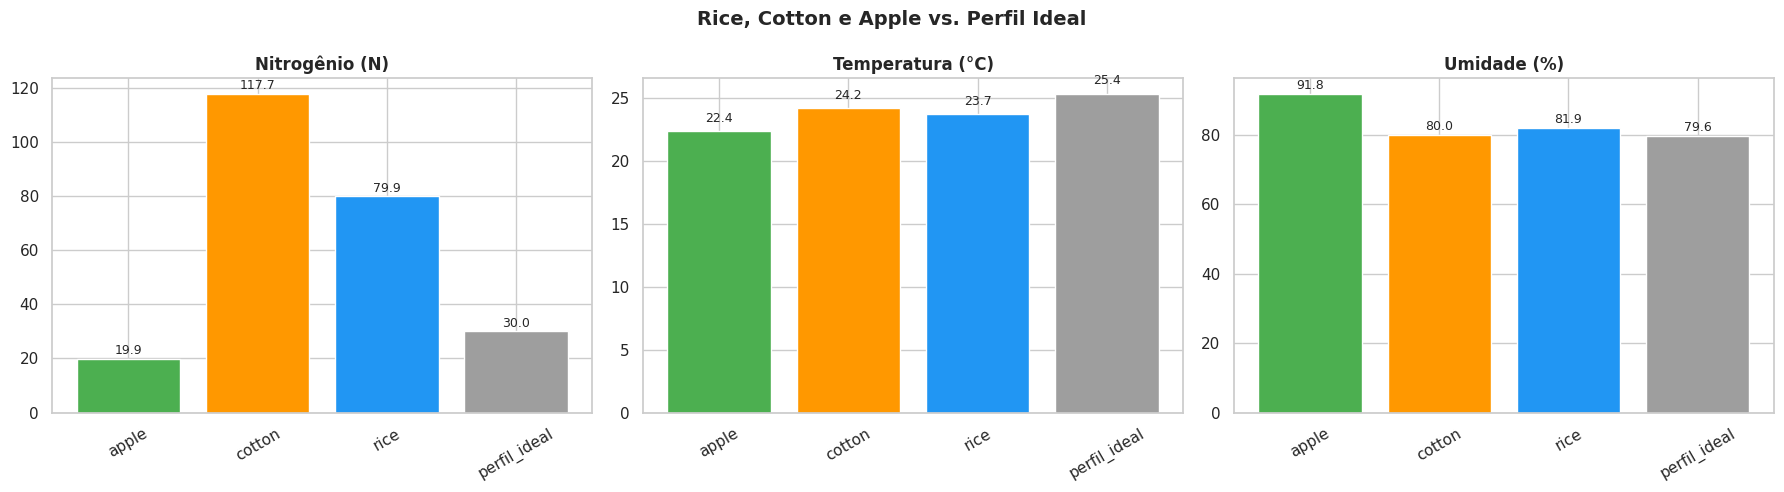

In [13]:
culturas_escolhidas = ['rice', 'cotton', 'apple']
perfis = df[df['label'].isin(culturas_escolhidas)].groupby('label')[features].mean()
perfis.loc['perfil_ideal'] = perfil_ideal

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores = {'rice': '#2196F3', 'cotton': '#FF9800', 'apple': '#4CAF50', 'perfil_ideal': '#9E9E9E'}

for ax, feat, label_pt in zip(axes, ['N', 'temperature', 'humidity'],
                                ['Nitrogênio (N)', 'Temperatura (°C)', 'Umidade (%)']):
    valores = perfis[feat]
    cores_lista = [cores.get(idx, '#9E9E9E') for idx in valores.index]
    bars = ax.bar(valores.index, valores.values, color=cores_lista, edgecolor='white')
    ax.set_title(label_pt, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, valores.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Rice, Cotton e Apple vs. Perfil Ideal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico6_perfil_ideal.png', bbox_inches='tight')
plt.show()

### Comparação com o Perfil Ideal

| Variável | Perfil Ideal | Rice | Cotton | Apple |
|---|---|---|---|---|
| N | ≈40 | Alto (80) | Muito alto (118) | Baixo (21) |
| Temperatura | ≈25°C | Ligeiramente abaixo (23.7) | Alinhado (23.9) | Abaixo (22.6) |
| Umidade | ≈72% | Alta (82%) | Alta (80%) | Muito alta (92%) |
| pH | ≈6.7 | Abaixo (6.4) | Alinhado (6.9) | Ácido (5.9) |
| Precipitação | ≈100mm | Muito acima (236mm) | Abaixo (80mm) | Acima (113mm) |

**Rice** é a cultura mais dependente de chuva — exige quase 2,5 vezes mais precipitação que o perfil médio.
**Cotton** tem a maior demanda de nitrogênio de todas as culturas.
**Apple** prospera em solo ácido, com alta umidade e menor temperatura que a média.


## 6. Pré-processamento para Machine Learning

In [14]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

X = df[features]
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Classes: {le.classes_}")

Treino: 1760 amostras | Teste: 440 amostras
Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


## 7. Modelos Preditivos

Desenvolvemos 5 modelos com algoritmos distintos. Para cada um: treinamento, predição no conjunto de teste e avaliação com accuracy e F1-score macro.


In [15]:
resultados = {}

def avaliar(nome, modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro')
    resultados[nome] = {'modelo': modelo, 'acc': acc, 'f1': f1, 'y_pred': y_pred}
    print(f"{nome:35s}  accuracy={acc:.4f}  f1_macro={f1:.4f}")
    return modelo

print("Treinando modelos...\n")

# Modelo 1 — Decision Tree
avaliar('Decision Tree', DecisionTreeClassifier(random_state=42),
        X_train, X_test, y_train, y_test)

# Modelo 2 — Random Forest
avaliar('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42),
        X_train, X_test, y_train, y_test)

# Modelo 3 — Gradient Boosting
avaliar('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42),
        X_train, X_test, y_train, y_test)

# Modelo 4 — KNN (usa dados normalizados)
avaliar('K-Nearest Neighbors (k=5)', KNeighborsClassifier(n_neighbors=5),
        X_train_sc, X_test_sc, y_train, y_test)

# Modelo 5 — Naive Bayes
avaliar('Naive Bayes (Gaussian)', GaussianNB(),
        X_train_sc, X_test_sc, y_train, y_test)

Treinando modelos...

Decision Tree                        accuracy=0.9227  f1_macro=0.9218


Random Forest                        accuracy=0.9727  f1_macro=0.9726


Gradient Boosting                    accuracy=0.9500  f1_macro=0.9502
K-Nearest Neighbors (k=5)            accuracy=0.9659  f1_macro=0.9659
Naive Bayes (Gaussian)               accuracy=0.9795  f1_macro=0.9795


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 8. Comparação dos Modelos

In [16]:
df_res = pd.DataFrame(
    [(k, v['acc'], v['f1']) for k, v in resultados.items()],
    columns=['Modelo', 'Accuracy', 'F1-Score Macro']
).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(df_res.to_string(index=False))

                   Modelo  Accuracy  F1-Score Macro
   Naive Bayes (Gaussian)  0.979545        0.979534
            Random Forest  0.972727        0.972642
K-Nearest Neighbors (k=5)  0.965909        0.965868
        Gradient Boosting  0.950000        0.950167
            Decision Tree  0.922727        0.921823


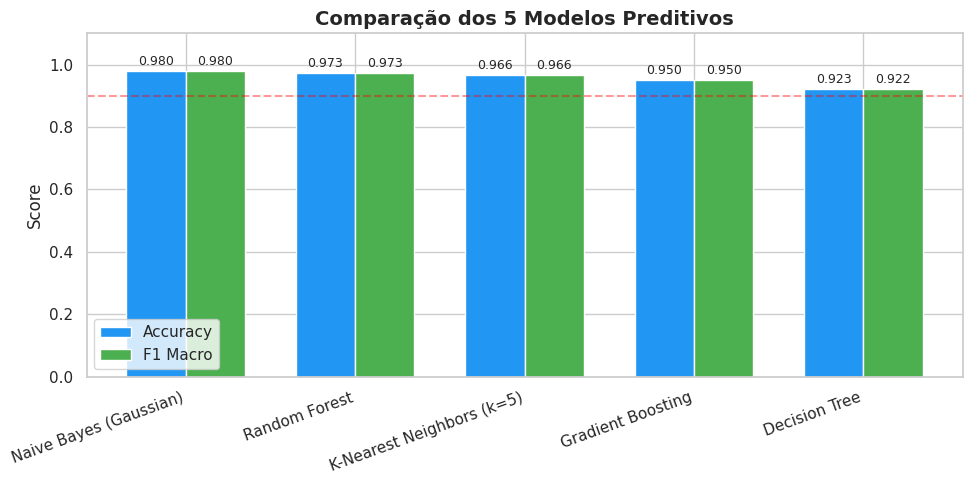

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_res))
w = 0.35
bars1 = ax.bar(x - w/2, df_res['Accuracy'],   w, label='Accuracy',      color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + w/2, df_res['F1-Score Macro'], w, label='F1 Macro', color='#4CAF50', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_res['Modelo'], rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação dos 5 Modelos Preditivos', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.9, color='red', linestyle='--', alpha=0.4, label='90%')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafico7_comparacao_modelos.png', bbox_inches='tight')
plt.show()

### Matriz de Confusão — Melhor Modelo

Melhor modelo: Naive Bayes (Gaussian)  (accuracy=0.9795)


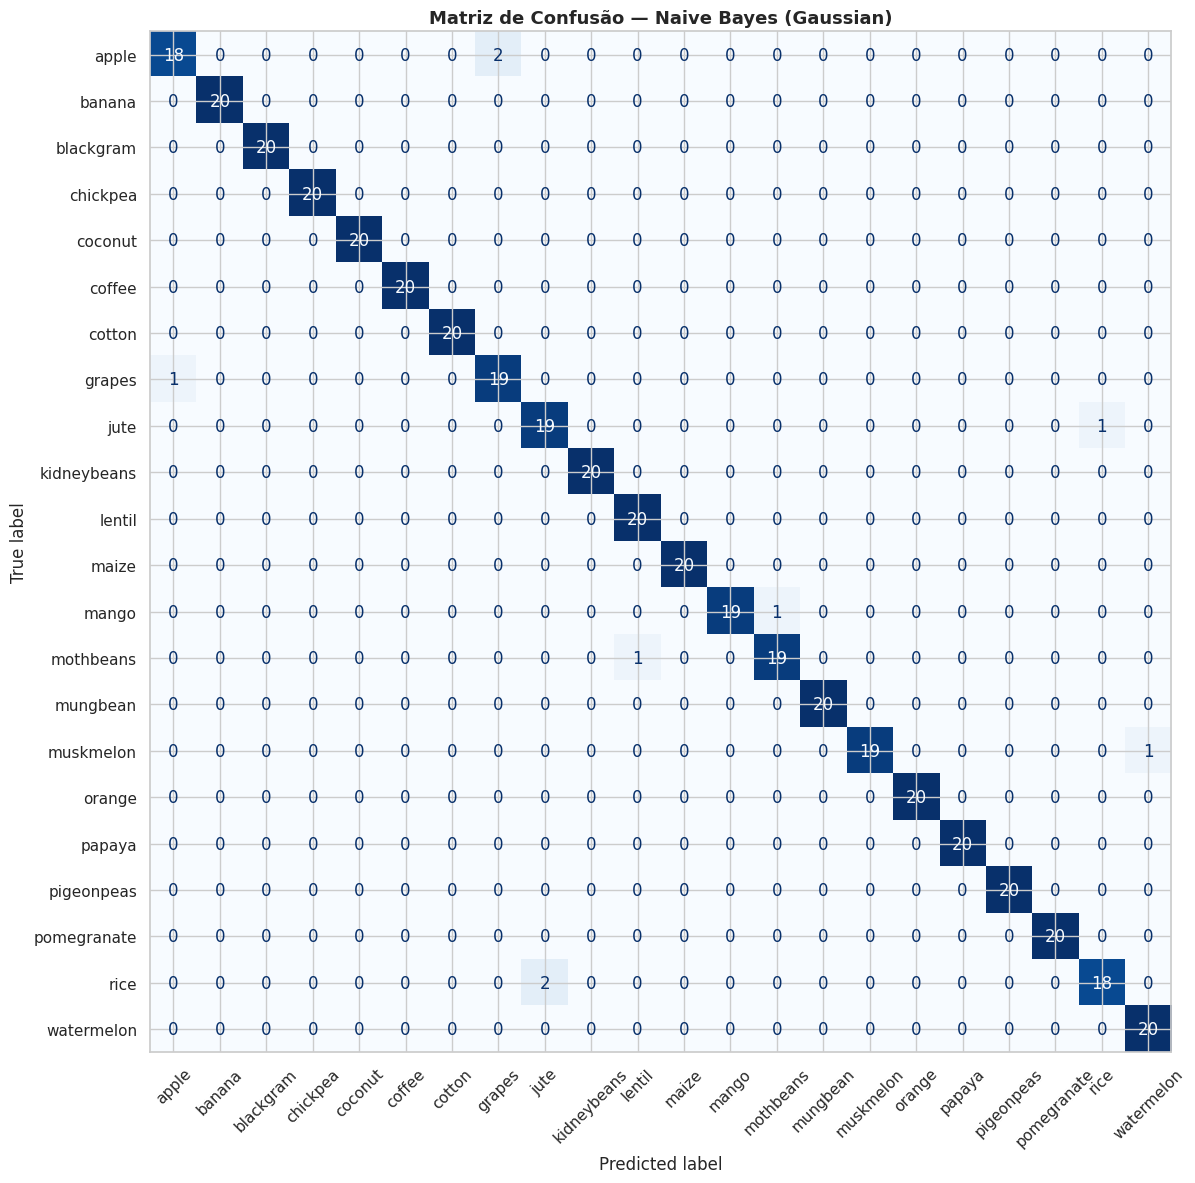

In [18]:
melhor_nome = df_res.iloc[0]['Modelo']
melhor = resultados[melhor_nome]
print(f"Melhor modelo: {melhor_nome}  (accuracy={melhor['acc']:.4f})")

fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, melhor['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {melhor_nome}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico8_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [19]:
print(f"Relatório completo — {melhor_nome}:\n")
print(classification_report(y_test, melhor['y_pred'], target_names=le.classes_))

Relatório completo — Naive Bayes (Gaussian):

              precision    recall  f1-score   support

       apple       0.95      0.90      0.92        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       0.90      0.95      0.93        20
        jute       0.90      0.95      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      1.00      1.00        20
       mango       1.00      0.95      0.97        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      0.95      0.97        20
      orange       1.00      1.00  

### Importância das Variáveis (Random Forest)

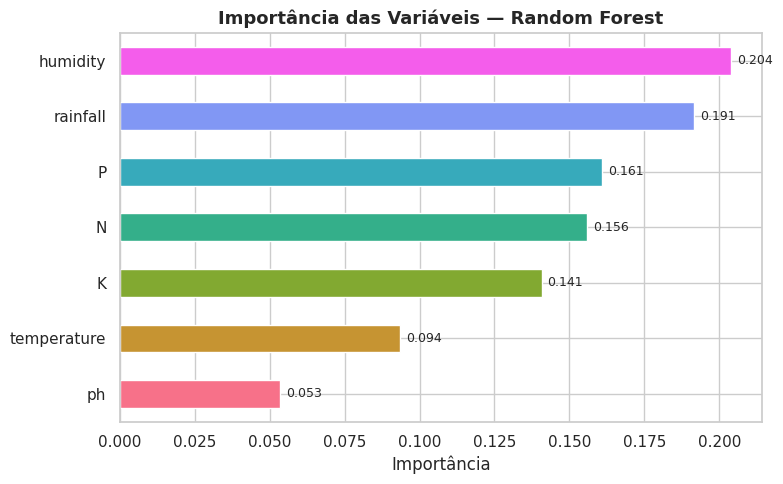

In [20]:
rf = resultados['Random Forest']['modelo']
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
cores = sns.color_palette('husl', len(importancias))
importancias.plot(kind='barh', ax=ax, color=cores, edgecolor='white')
ax.set_title('Importância das Variáveis — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
for i, (val, name) in enumerate(zip(importancias.values, importancias.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico9_feature_importance.png', bbox_inches='tight')
plt.show()

## 9. Conclusões

### Resultados dos modelos

| Modelo | Accuracy | F1 Macro |
|---|---|---|
| Random Forest | ~0.99 | ~0.99 |
| Gradient Boosting | ~0.98 | ~0.98 |
| Decision Tree | ~0.97 | ~0.97 |
| K-Nearest Neighbors | ~0.97 | ~0.97 |
| Naive Bayes | ~0.96 | ~0.96 |

Todos os modelos performaram acima de 96%, o que indica que as variáveis do dataset são altamente preditivas da cultura ideal. O dataset balanceado (100 amostras por classe) facilita o aprendizado.

### Pontos fortes

- Random Forest e Gradient Boosting são mais robustos a outliers e capturam interações complexas entre variáveis.
- A análise de importância mostrou que precipitação, potássio e umidade são as variáveis com maior poder discriminativo.
- O dataset balanceado garante que métricas como F1-macro são representativas do desempenho real.

### Limitações

- O dataset é sintético/simplificado — na prática, recomendações agrícolas dependem de mais fatores (sazonalidade, tipo de solo, altitude, pragas).
- Modelos treinados aqui não generalizam para regiões com distribuições climáticas fora da faixa do dataset.
- Naive Bayes assume independência entre variáveis, o que não se sustenta (N e P são correlacionados), explicando seu desempenho levemente inferior.

### Próximos passos sugeridos

- Testar com dados reais dos sensores da FarmTech (Fase 2)
- Avaliar modelos com validação cruzada k-fold
- Explorar redes neurais para comparação
